# Dollar Neutral: V Long / MA Short (Dynamic Hedge Ratio)

This notebook demonstrates a **dynamic hedge ratio** approach for the Dollar Neutral strategy
using Visa (V) as the long leg and Mastercard (MA) as the short leg.

Instead of a fixed 1:1 ratio, we calculate the hedge ratio based on **60-day rolling volatility**:
- **Target Ratio = Volatility(Long) / Volatility(Short)**
- This ensures equal risk contribution from both positions
- Aims to improve Sharpe Ratio while maintaining market neutrality

BIL (SPDR Bloomberg 1-3 Month T-Bill ETF) absorbs collateral and residual cash.

**Data**: Yahoo Finance (auto-adjusted)  
**Rebalance**: Monthly mid-month (`month_mid` = 15th of each month)  
**Volatility Window**: 60 trading days (~3 months)  

**Rationale**: Fixed 50/50 allocation achieved beta reduction but low Sharpe Ratio.
Dynamic volatility-based sizing should equalize risk contributions and improve risk-adjusted returns.

# Notebook Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Import tiportfolio modules
from tiportfolio.helpers.cache import enable_data_source_cache
from tiportfolio.helpers.data import YFinance
from tiportfolio import (
    DollarNeutral, FixRatio, Schedule, ScheduleBasedEngine,
    compare_strategies, plot_strategy_comparison_interactive,
    rebalance_decisions_table,
)

# Enable caching for data fetching
enable_data_source_cache("tiportfolio", cache_dir=".cache")

# Define assets and parameters
LONG   = "V"
SHORT  = "MA"
CASH   = "BIL"
VOLATILITY_WINDOW = 60  # 60 trading days for rolling volatility
START  = "2023-01-01"   # Extended start for better analysis
END    = "2024-12-31"
INITIAL_VALUE = 10_000

symbols = [LONG, SHORT, CASH]

print(f"Dynamic Hedge Ratio Setup:")
print(f"Long Asset: {LONG}")
print(f"Short Asset: {SHORT}")
print(f"Cash Asset: {CASH}")
print(f"Volatility Window: {VOLATILITY_WINDOW} days")

Dynamic Hedge Ratio Setup:
Long Asset: V
Short Asset: MA
Cash Asset: BIL
Volatility Window: 60 days


## Data Loading and Preparation

Load historical price data for V, MA, and BIL to prepare for backtesting.

In [2]:
# Set up data fetcher
yf = YFinance(auto_adjust=True)

print(f"Loading data for {symbols} from {START} to {END}...")

# Fetch price data
df = yf.query(symbols, START, END)

prices = {}
for symbol in df["symbol"].unique():
    sub = df[df["symbol"] == symbol].set_index("date")[["open", "high", "low", "close"]]
    prices[symbol] = sub

# Display data summary
for symbol, df in prices.items():
    print(f"{symbol}: {len(df)} trading days from {df.index[0].date()} to {df.index[-1].date()}")
    
# Show sample data
print("\nSample price data:")
for symbol in symbols:
    print(f"\n{symbol} (last 5 days):")
    print(prices[symbol].tail())

Loading data for ['V', 'MA', 'BIL'] from 2023-01-01 to 2024-12-31...
Loaded cached bar data.

MA: 501 trading days from 2023-01-03 to 2024-12-30
V: 501 trading days from 2023-01-03 to 2024-12-30
BIL: 501 trading days from 2023-01-03 to 2024-12-30

Sample price data:

V (last 5 days):
                  open        high         low       close
date                                                      
2024-12-23  312.778898  315.077803  310.499831  314.334625
2024-12-24  315.276006  318.615348  314.394087  317.733429
2024-12-26  316.861413  318.526155  316.554235  317.991058
2024-12-27  316.365973  318.575700  314.671535  315.761536
2024-12-30  311.817712  314.225601  310.380919  312.441986

MA (last 5 days):
                  open        high         low       close
date                                                      
2024-12-23  522.041958  525.586247  517.375804  525.149414
2024-12-24  525.457221  531.880582  524.027592  531.850830
2024-12-26  529.785732  533.826419  529.080825 

# Baseline Fixed Ratio Backtest

Create a baseline backtest using the fixed 50/50 ratio for comparison.

In [3]:
# Symmetric book sizes (50/50)
RATIO_BS = 1.0
LONG_BS  = 1.0 / (1.0 + RATIO_BS)   # = 0.5
SHORT_BS = RATIO_BS / (1.0 + RATIO_BS)  # = 0.5
print(f"long_book_size={LONG_BS:.4f}  short_book_size={SHORT_BS:.4f}  ratio={SHORT_BS/LONG_BS:.4f}")

# Create baseline fixed ratio strategy for comparison
baseline_strategy = DollarNeutral(
    long_weights={LONG: 1.0},
    short_weights={SHORT: 1.0},
    cash_symbol=CASH,
    long_book_size=LONG_BS,
    short_book_size=SHORT_BS,
    tolerance=0.05,
)

# Set up baseline backtest
baseline_engine = ScheduleBasedEngine(
    allocation=baseline_strategy,
    rebalance=Schedule("month_mid"),
    fee_per_share=0.0035,
    initial_value=INITIAL_VALUE,
)

print("Running baseline fixed ratio backtest...")
baseline_result = baseline_engine.run(
    symbols=symbols,
    start=START, 
    end=END,
    prices_df=prices
)

# Display baseline results
print(baseline_result.summary())

long_book_size=0.5000  short_book_size=0.5000  ratio=1.0000
Running baseline fixed ratio backtest...
Backtest Summary
----------------
Sharpe Ratio:        0.1230
Sortino Ratio:       0.1700
MAR Ratio:           0.8118
CAGR:                4.66%
Max Drawdown:        5.73%
Kelly Leverage:      2.0112
Mean Excess Return:  0.0075
Final Value:         10,947.99
Total Fee:           0.06
Rebalances:          24


# Dynamic Ratio Implementation

##  Rolling Volatility Calculation

Implement the volatility calculation function using 60-day rolling standard deviation.

Rolling Volatility Calculation (Window: 60 days)
Long Asset (V) - Latest Volatility: 0.1790
Short Asset (MA) - Latest Volatility: 0.1568
Volatility Ratio (Long/Short): 1.1414

Volatility Statistics:
V - Mean: 0.1584, Std: 0.0281, Min: 0.1032, Max: 0.2192
MA - Mean: 0.1613, Std: 0.0218, Min: 0.1116, Max: 0.1993


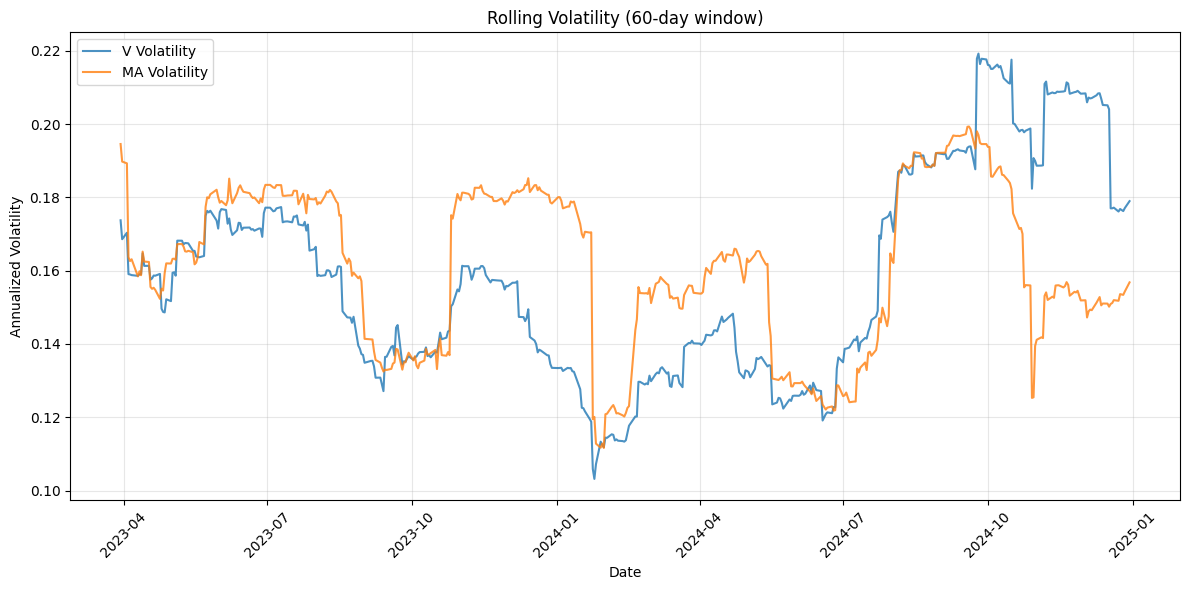

In [4]:
def calculate_rolling_volatility(prices_dict, long_symbol, short_symbol, window=VOLATILITY_WINDOW):
    """
    Calculate rolling volatility for long and short assets.
    
    Args:
        prices_dict: Dictionary of price DataFrames
        long_symbol: Symbol for long asset (V)
        short_symbol: Symbol for short asset (MA)
        window: Rolling window size in days
    
    Returns:
        tuple: (long_volatility, short_volatility) as pandas Series
    """
    # Extract close prices for both assets
    long_prices = prices_dict[long_symbol]['close']
    short_prices = prices_dict[short_symbol]['close']
    
    # Calculate daily returns
    long_returns = long_prices.pct_change()
    short_returns = short_prices.pct_change()
    
    # Calculate rolling volatility (annualized)
    long_volatility = long_returns.rolling(window=window).std() * np.sqrt(252)
    short_volatility = short_returns.rolling(window=window).std() * np.sqrt(252)
    
    return long_volatility, short_volatility

# Test the volatility calculation
long_vol, short_vol = calculate_rolling_volatility(prices, LONG, SHORT, VOLATILITY_WINDOW)

print(f"Rolling Volatility Calculation (Window: {VOLATILITY_WINDOW} days)")
print(f"Long Asset ({LONG}) - Latest Volatility: {long_vol.iloc[-1]:.4f}")
print(f"Short Asset ({SHORT}) - Latest Volatility: {short_vol.iloc[-1]:.4f}")
print(f"Volatility Ratio (Long/Short): {long_vol.iloc[-1]/short_vol.iloc[-1]:.4f}")

# Show volatility statistics
print("\nVolatility Statistics:")
print(f"{LONG} - Mean: {long_vol.mean():.4f}, Std: {long_vol.std():.4f}, Min: {long_vol.min():.4f}, Max: {long_vol.max():.4f}")
print(f"{SHORT} - Mean: {short_vol.mean():.4f}, Std: {short_vol.std():.4f}, Min: {short_vol.min():.4f}, Max: {short_vol.max():.4f}")

# Plot volatility series
plt.figure(figsize=(12, 6))
plt.plot(long_vol.index, long_vol, label=f'{LONG} Volatility', alpha=0.8)
plt.plot(short_vol.index, short_vol, label=f'{SHORT} Volatility', alpha=0.8)
plt.title(f'Rolling Volatility ({VOLATILITY_WINDOW}-day window)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dynamic Hedge Ratio Formula
Calculate the target ratio based on relative volatilities and convert to portfolio weights with bounds to prevent extreme allocations.

Dynamic Hedge Ratio Analysis
Current Raw Ratio (V/MA): 1.1414
Current Clamped Ratio: 1.1414
Ratio Range: 0.6968 to 1.5202

Corresponding Weights:
  Long (V): 0.4670 (46.7%)
  Short (MA): 0.5330 (53.3%)


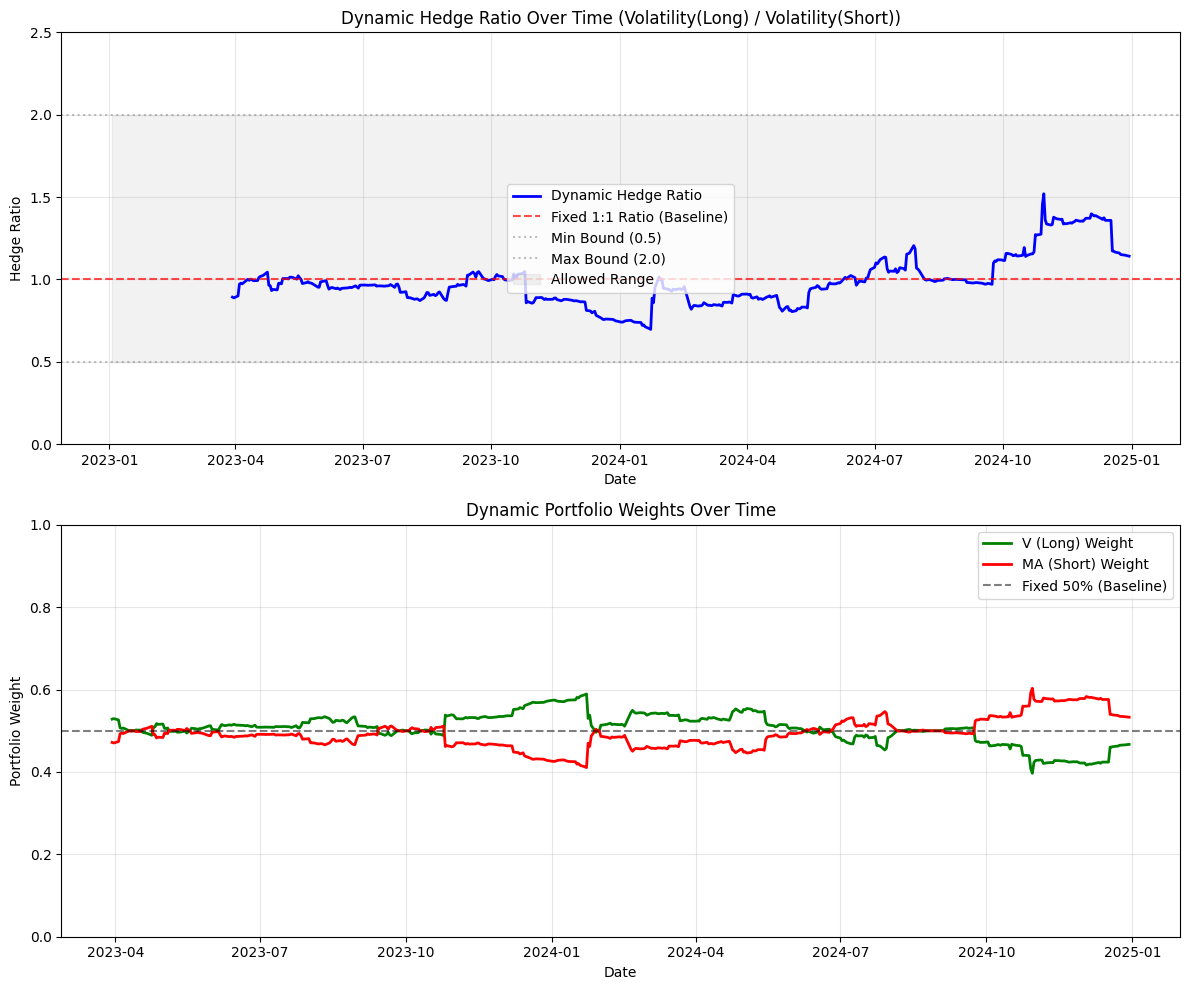


Dynamic Ratio Statistics:
  Mean: 0.9868
  Median: 0.9692
  Std: 0.1505
  Min: 0.6968
  Max: 1.5202

Weight Range:
  V: nan% to nan%
  MA: nan% to nan%


In [5]:
def calculate_dynamic_hedge_ratio(long_vol, short_vol, min_ratio=0.5, max_ratio=2.0):
    """
    Calculate dynamic hedge ratio based on relative volatilities.
    
    Formula: Target Ratio = Volatility(Long) / Volatility(Short)
    
    Args:
        long_vol: Rolling volatility series for long asset
        short_vol: Rolling volatility series for short asset
        min_ratio: Minimum allowed ratio to prevent extreme allocations
        max_ratio: Maximum allowed ratio to prevent extreme allocations
    
    Returns:
        pandas Series: Dynamic hedge ratio (long exposure / short exposure)
    """
    # Calculate raw ratio
    raw_ratio = long_vol / short_vol
    
    # Clamp to bounds to prevent extreme allocations
    dynamic_ratio = raw_ratio.clip(lower=min_ratio, upper=max_ratio)
    
    return dynamic_ratio

# Calculate dynamic hedge ratio
dynamic_ratio = calculate_dynamic_hedge_ratio(long_vol, short_vol, min_ratio=0.5, max_ratio=2.0)

# Calculate weights from ratio
# If ratio = 1.0: equal weights (50/50)
# If ratio > 1.0: more weight to short (long is more volatile)
# If ratio < 1.0: more weight to long (short is more volatile)
def ratio_to_weights(ratio, long_symbol, short_symbol):
    """
    Convert hedge ratio to portfolio weights.
    
    Weight(Long) = 1 / (1 + ratio)
    Weight(Short) = ratio / (1 + ratio)
    
    Returns dictionary of weights.
    """
    long_weight = 1.0 / (1.0 + ratio)
    short_weight = ratio / (1.0 + ratio)
    return {long_symbol: long_weight, short_symbol: short_weight}

# Test the conversion with current ratio
current_ratio = dynamic_ratio.iloc[-1]
current_weights = ratio_to_weights(current_ratio, LONG, SHORT)

print(f"Dynamic Hedge Ratio Analysis")
print(f"=" * 40)
print(f"Current Raw Ratio (V/MA): {(long_vol/short_vol).iloc[-1]:.4f}")
print(f"Current Clamped Ratio: {current_ratio:.4f}")
print(f"Ratio Range: {dynamic_ratio.min():.4f} to {dynamic_ratio.max():.4f}")
print(f"\nCorresponding Weights:")
print(f"  Long ({LONG}): {current_weights[LONG]:.4f} ({current_weights[LONG]*100:.1f}%)")
print(f"  Short ({SHORT}): {current_weights[SHORT]:.4f} ({current_weights[SHORT]*100:.1f}%)")

# Plot the dynamic ratio over time
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Dynamic Hedge Ratio
ax1 = axes[0]
ax1.plot(dynamic_ratio.index, dynamic_ratio, label='Dynamic Hedge Ratio', color='blue', linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Fixed 1:1 Ratio (Baseline)')
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Min Bound (0.5)')
ax1.axhline(y=2.0, color='gray', linestyle=':', alpha=0.5, label='Max Bound (2.0)')
ax1.fill_between(dynamic_ratio.index, 0.5, 2.0, alpha=0.1, color='gray', label='Allowed Range')
ax1.set_title('Dynamic Hedge Ratio Over Time (Volatility(Long) / Volatility(Short))')
ax1.set_xlabel('Date')
ax1.set_ylabel('Hedge Ratio')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 2.5)

# Plot 2: Portfolio Weights Over Time
ax2 = axes[1]
long_weights = [ratio_to_weights(r, LONG, SHORT)[LONG] for r in dynamic_ratio]
short_weights = [ratio_to_weights(r, LONG, SHORT)[SHORT] for r in dynamic_ratio]

ax2.plot(dynamic_ratio.index, long_weights, label=f'{LONG} (Long) Weight', color='green', linewidth=2)
ax2.plot(dynamic_ratio.index, short_weights, label=f'{SHORT} (Short) Weight', color='red', linewidth=2)
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Fixed 50% (Baseline)')
ax2.set_title('Dynamic Portfolio Weights Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Portfolio Weight')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Show summary statistics
print(f"\n{'='*40}")
print(f"Dynamic Ratio Statistics:")
print(f"  Mean: {dynamic_ratio.mean():.4f}")
print(f"  Median: {dynamic_ratio.median():.4f}")
print(f"  Std: {dynamic_ratio.std():.4f}")
print(f"  Min: {dynamic_ratio.min():.4f}")
print(f"  Max: {dynamic_ratio.max():.4f}")
print(f"\nWeight Range:")
print(f"  {LONG}: {min(long_weights)*100:.1f}% to {max(long_weights)*100:.1f}%")
print(f"  {SHORT}: {min(short_weights)*100:.1f}% to {max(short_weights)*100:.1f}%")

### Custom Allocation Strategy for Dynamic Weights
Create a custom `DollarNeutralDynamic` class that integrates with `ScheduleBasedEngine` and generates dynamic weights on each rebalance date based on rolling volatility.

In [11]:
class DollarNeutralDynamic:
    """
    Dynamic Dollar Neutral allocation strategy.
    
    Adjusts hedge ratio based on relative volatilities of long and short assets.
    Uses rolling 60-day volatility to determine optimal weights.
    """
    
    def __init__(
        self,
        long_symbol: str,
        short_symbol: str,
        cash_symbol: str,
        prices_dict: dict,
        volatility_window: int = 60,
        min_ratio: float = 0.5,
        max_ratio: float = 2.0,
        long_book_size: float = 0.5,
        short_book_size: float = 0.5,
        tolerance: float = 0.05,
    ):
        """
        Initialize dynamic dollar neutral strategy.
        
        Args:
            long_symbol: Symbol for long leg
            short_symbol: Symbol for short leg
            cash_symbol: Symbol for cash/collateral
            prices_dict: Dictionary of price DataFrames
            volatility_window: Days for rolling volatility calculation
            min_ratio: Minimum hedge ratio bound
            max_ratio: Maximum hedge ratio bound
            long_book_size: Target long book size (0.5 for 50%)
            short_book_size: Target short book size (0.5 for 50%)
            tolerance: Rebalancing tolerance
        """
        self.long_symbol = long_symbol
        self.short_symbol = short_symbol
        self.cash_symbol = cash_symbol
        self.prices_dict = prices_dict
        self.volatility_window = volatility_window
        self.min_ratio = min_ratio
        self.max_ratio = max_ratio
        self.long_book_size = long_book_size
        self.short_book_size = short_book_size
        self.tolerance = tolerance
        
        # Pre-calculate volatility series
        self.long_vol, self.short_vol = self._calculate_volatility()
        self.dynamic_ratio = self._calculate_dynamic_ratio()
        
    def _calculate_volatility(self):
        """Calculate rolling volatility for both assets."""
        long_returns = self.prices_dict[self.long_symbol]['close'].pct_change()
        short_returns = self.prices_dict[self.short_symbol]['close'].pct_change()
        
        long_vol = long_returns.rolling(window=self.volatility_window).std() * np.sqrt(252)
        short_vol = short_returns.rolling(window=self.volatility_window).std() * np.sqrt(252)
        
        return long_vol, short_vol
    
    def _calculate_dynamic_ratio(self):
        """Calculate dynamic hedge ratio with bounds."""
        raw_ratio = self.long_vol / self.short_vol
        return raw_ratio.clip(lower=self.min_ratio, upper=self.max_ratio)
    
    def get_symbols(self):
        """Return list of symbols used by this strategy."""
        return [self.long_symbol, self.short_symbol, self.cash_symbol]
    
    def get_target_weights(self, date, total_equity, positions_dollars, prices_row, **context):
        """
        Generate dynamic target weights for a given rebalance date.
        
        Args:
            date: Rebalance date (pd.Timestamp)
            total_equity: Total portfolio equity
            positions_dollars: Current positions in dollars
            prices_row: Current prices
            **context: Additional context from engine
            
        Returns:
            dict: Target weights {symbol: weight}
        """
        # Get volatility ratio for this date (or last available)
        if date in self.dynamic_ratio.index:
            ratio = self.dynamic_ratio.loc[date]
        else:
            # Use last available ratio
            ratio = self.dynamic_ratio.iloc[-1]
        
        # Handle NaN (insufficient data at start)
        if pd.isna(ratio):
            ratio = 1.0  # Default to 1:1 ratio
        
        # Convert ratio to weights within the book
        # long_weight + short_weight = 1.0 (within the book)
        long_weight_in_book = 1.0 / (1.0 + ratio)
        short_weight_in_book = ratio / (1.0 + ratio)
        
        # Scale by book sizes
        # Total portfolio: long_book + short_book + cash = 1.0
        long_weight = long_weight_in_book * (self.long_book_size + self.short_book_size)
        short_weight = short_weight_in_book * (self.long_book_size + self.short_book_size)
        cash_weight = 1.0 - long_weight - short_weight
        
        weights = {
            self.long_symbol: long_weight,
            self.short_symbol: short_weight,
            self.cash_symbol: cash_weight,
        }
        
        return weights

# Create dynamic strategy instance
dynamic_strategy = DollarNeutralDynamic(
    long_symbol=LONG,
    short_symbol=SHORT,
    cash_symbol=CASH,
    prices_dict=prices,
    volatility_window=VOLATILITY_WINDOW,
    min_ratio=0.5,
    max_ratio=2.0,
    long_book_size=LONG_BS,
    short_book_size=SHORT_BS,
    tolerance=0.05,
)

# Test the strategy
print("Dynamic Strategy Test")
print("=" * 40)
print(f"Symbols: {dynamic_strategy.get_symbols()}")

# Test weight generation for a few dates
sample_dates = [
    pd.Timestamp("2023-06-15"),  # Mid 2023
    pd.Timestamp("2023-12-15"),  # End 2023
    pd.Timestamp("2024-06-17"),  # Mid 2024
    pd.Timestamp("2024-12-16"),  # End 2024
]

print(f"\nSample Weights on Rebalance Dates:")
print("-" * 60)
print(f"{'Date':<15} {'Ratio':<8} {'Long':<10} {'Short':<10} {'Cash':<10}")
print("-" * 60)

for date in sample_dates:
    if date in prices[LONG].index:
        weights = dynamic_strategy.get_target_weights(
            date=date,
            total_equity=INITIAL_VALUE,
            positions_dollars={},
            prices_row=None,
        )
        ratio = dynamic_strategy.dynamic_ratio.loc[date] if date in dynamic_strategy.dynamic_ratio.index else 1.0
        if pd.isna(ratio):
            ratio = 1.0
        print(f"{date.strftime('%Y-%m-%d'):<15} {ratio:<8.3f} {weights[LONG]:<10.3f} {weights[SHORT]:<10.3f} {weights[CASH]:<10.3f}")

print("-" * 60)
print(f"\nDynamic Strategy Ready for Backtesting!")
print(f"Integration: Can be passed to ScheduleBasedEngine(allocation=dynamic_strategy)")

Dynamic Strategy Test
Symbols: ['V', 'MA', 'BIL']

Sample Weights on Rebalance Dates:
------------------------------------------------------------
Date            Ratio    Long       Short      Cash      
------------------------------------------------------------
2023-06-15      0.939    0.516      0.484      0.000     
2023-12-15      0.782    0.561      0.439      0.000     
2024-06-17      1.011    0.497      0.503      0.000     
2024-12-16      1.358    0.424      0.576      0.000     
------------------------------------------------------------

Dynamic Strategy Ready for Backtesting!
Integration: Can be passed to ScheduleBasedEngine(allocation=dynamic_strategy)
